In [1]:
import mlflow
import torch
import os
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath('../../mlflow.db')}")

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_dataset = datasets.MNIST(root='../../datasets', train = True, download = False, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root = '../../datasets', train = False, download = False, transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
class ModelDynamicLayers(nn.Module):
    def __init__(self, hidden_sizes):
        super().__init__()

        layers = []
        input_size = 784

        layers.append(nn.Flatten())

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))
        self.sequential = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.sequential(x)

In [4]:
mlflow.set_experiment("mnist-mlp")

with mlflow.start_run(run_name="baseline-softmax-linear"):
    mlflow.log_param("architecture", "784-10")
    mlflow.log_param("hidden_layers", 0)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_metric("test_accuracy", 0.9274)



(0) : 0.30000153530254037
(1) : 0.1286162166282344
(2) : 0.08498744262970173
(3) : 0.061880553369102545
(4) : 0.04568899709193695
(5) : 0.03365138366342838
(6) : 0.02675982171457126
(7) : 0.02168527017878706
(8) : 0.01610956222872247
(9) : 0.012547079897694179
(10) : 0.011452922247288657
(11) : 0.008624782611801872
(12) : 0.008014148204982195
(13) : 0.005888934065254117
(14) : 0.006104603532122307
(15) : 0.007589881847712965
(16) : 0.0036874776833932966
(17) : 0.0027349262687350545
(18) : 0.005787085678380722
(19) : 0.0035644089369858242
0.9806


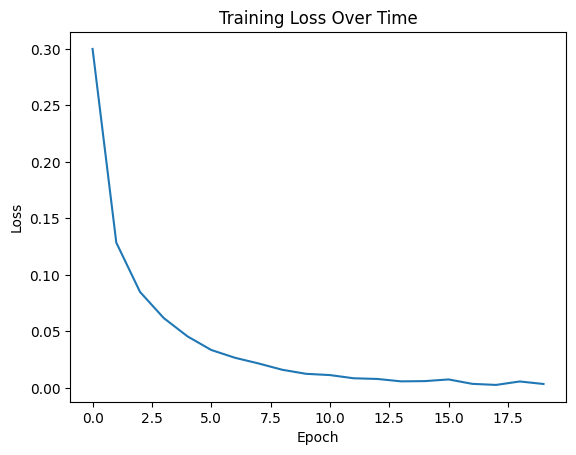

In [5]:
with mlflow.start_run(run_name="mlp-1layer"):
    mlflow.log_param("architecture", "784-256-10")
    mlflow.log_param("hidden_layers", 1)
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)

    model_1layer = ModelDynamicLayers([256]).to(device)
    model_1layer.train()


    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_1layer.parameters(), lr = 0.001)

    loss_list = []

    for epoch in range(20):
        loss_sum = 0
        batch_num = 0
        
        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)    

            batch_num += 1
            optimizer.zero_grad()
            outputs = model_1layer(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item()
            loss.backward()
            optimizer.step()
        
        
        print(f"({epoch}) : {loss_sum/batch_num}")
        loss_list.append(loss_sum/batch_num)
    
    model_1layer.eval()

    correct = 0
    samples = 0

    preds = []
    true = []

    for images, labels in test_loader:
        with torch.no_grad():

            images, labels = images.to(device), labels.to(device)    
            
            outputs = model_1layer(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            samples += labels.size(0)
            
            preds.extend(predicted.tolist())
            true.extend(labels.tolist())
            
    accuracy = correct/samples
    mlflow.log_metric("test_accuracy", accuracy)
    print(accuracy)

    plt.plot(loss_list)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()



(0) : 0.2837943259134158
(1) : 0.10936509817640093
(2) : 0.07300454758004403
(3) : 0.05290247282650727
(4) : 0.039727199356630646
(5) : 0.032094648979387796
(6) : 0.024415709987977274
(7) : 0.021301930823443664
(8) : 0.018974711901740295
(9) : 0.01587230766830765
(10) : 0.014875651654218596
(11) : 0.011519220410604915
(12) : 0.01249242886840367
(13) : 0.01083064868211206
(14) : 0.009374822607470922
(15) : 0.01005868980517917
(16) : 0.010028992319544903
(17) : 0.007093065952862281
(18) : 0.009545961698424933
(19) : 0.007321413406696511
0.9823


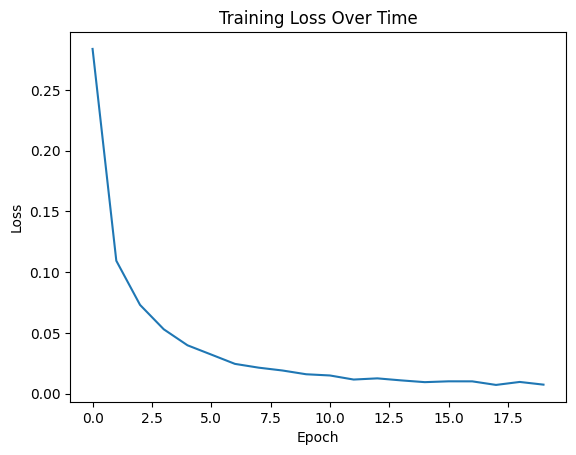

In [7]:
with mlflow.start_run(run_name="mlp-2layers"):
    mlflow.log_param("architecture", "784-256-128-10")
    mlflow.log_param("hidden_layers", 1)
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)

    model_2layers = ModelDynamicLayers([256, 128]).to(device)
    model_2layers.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_2layers.parameters(), lr = 0.001)

    loss_list = []

    for epoch in range(20):
        loss_sum = 0
        batch_num = 0
        
        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)    

            batch_num += 1
            optimizer.zero_grad()
            outputs = model_2layers(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item()
            loss.backward()
            optimizer.step()
        
        
        print(f"({epoch}) : {loss_sum/batch_num}")
        loss_list.append(loss_sum/batch_num)
    
    model_2layers.eval()

    correct = 0
    samples = 0

    preds = []
    true = []

    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)    

        with torch.no_grad():
            outputs = model_2layers(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            samples += labels.size(0)
            
            preds.extend(predicted.tolist())
            true.extend(labels.tolist())
            
    accuracy = correct/samples
    mlflow.log_metric("test_accuracy", accuracy)
    print(accuracy)

    plt.plot(loss_list)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()



In [ ]:
with mlflow.start_run(run_name="mlp-3layers"):
    mlflow.log_param("architecture", "784-256-128-64-10")
    mlflow.log_param("hidden_layers", 1)
    mlflow.log_param("activation", "ReLU")
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("learning_rate", 0.001)

    model_3layers = ModelDynamicLayers([256, 128, 64]).to(device)
    model_3layers.train()

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model_3layers.parameters(), lr = 0.001)

    loss_list = []

    for epoch in range(20):
        loss_sum = 0
        batch_num = 0
        
        for images, labels in train_loader:
            batch_num += 1
            optimizer.zero_grad()
            outputs = model_3layers(images)
            loss = criterion(outputs, labels)
            loss_sum += loss.item()
            loss.backward()
            optimizer.step()
        
        
        print(f"({epoch}) : {loss_sum/batch_num}")
        loss_list.append(loss_sum/batch_num)
    
    model_3layers.eval()

    correct = 0
    samples = 0

    preds = []
    true = []

    for images, labels in test_loader:
        with torch.no_grad():
            outputs = model_3layers(images)
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            samples += labels.size(0)
            
            preds.extend(predicted.tolist())
            true.extend(labels.tolist())
            
    accuracy = correct/samples
    mlflow.log_metric("test_accuracy", accuracy)
    print(accuracy)

    plt.plot(loss_list)
    plt.title('Training Loss Over Time')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

